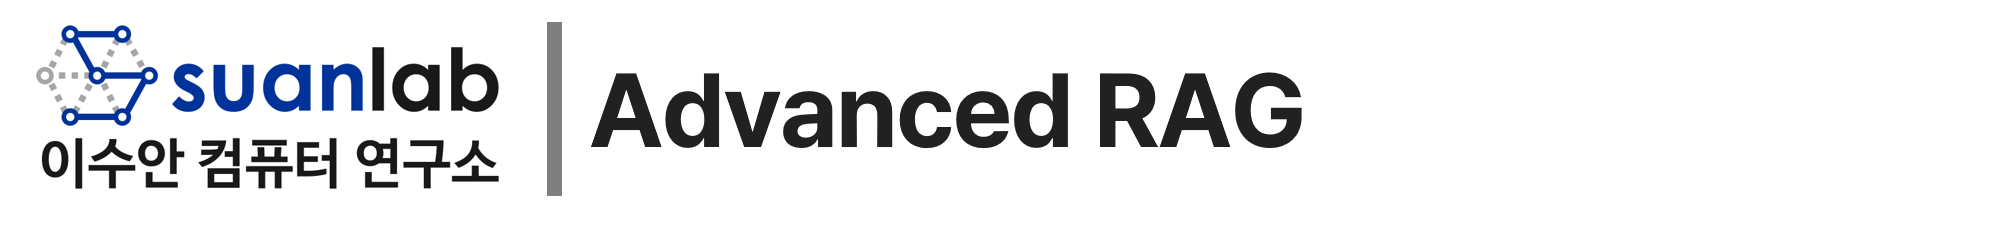

# 🤖 Agentic RAG & 쿼리 라우팅

## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" sentence-transformers faiss-cpu rank_bm25 networkx pandas matplotlib

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 59.3 MB/s eta 0:00:00
Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


---
# Agentic RAG (검색을 '도구'로 쓰는 에이전트)

## 학습목표
- 검색(retrieval)을 **한 번 하고 끝**내는 대신, **Claude가 필요할 때마다 스스로 검색을 반복**하게 만듦(검색을 도구(tool)로 노출)
- 답이 부족하면 **추가 질문을 만들어 다시 검색**하고, 충분하면 멈추는 **에이전트 루프**를 직접 구현(self-RAG 맛보기)
- 같은 multi-hop 질문에서 **① 벡터 단발 검색 RAG**와 **② 에이전트 반복 검색 RAG**를 비교
- 이 과정은 **Agentic AI** 과정으로 "검색을 도구로 쥐어주고 에이전트가 알아서 여러 번 찾게 한다"가 Agentic RAG의 핵심

## 사전개념
- RAG 흐름(청킹 → 임베딩 → 벡터검색 → Claude 답변), tool_use(도구 호출)

## 용어 미니 사전 (Agentic RAG 편)

| 용어 | 한 줄 뜻 |
|---|---|
| **단발 검색(single-shot)** | 질문을 한 번만 검색해 나온 자료로 바로 답함 |
| **에이전트 루프(agent loop)** | Claude가 도구(검색)를 부르고 → 결과를 보고 → 또 부를지 스스로 결정하는 반복 |
| **tool_use(도구 호출)** | Claude가 "이 함수를 이 입력으로 실행해줘"라고 요청하는 기능 |
| **multi-hop 질문** | 답을 찾으려면 *여러 단계*를 거쳐야 하는 질문(A→B→C) |
| **self-RAG** | 검색 결과가 충분한지 모델이 스스로 평가하고, 부족하면 다시 검색하는 방식 |

> 쉽게 말하면 단발 검색 = 도서관에서 책 한 권만 뽑아 답하기  
에이전트 검색 = 필요하면 몇 번이고 책장으로 돌아가 단서를 이어 붙이기


## 왜 '에이전트 검색'이 필요한가
- **multi-hop 질문**(여러 단계를 거쳐야 답이 나오는 질문)을 생각해 봄

> *"노바테크 CEO가 이끄는 회사의 최대 경쟁사가 만드는 주력 제품은 무엇인가?"*

- 이걸 풀려면: ① 노바테크 CEO가 누구/어느 회사인지 → ② 그 회사의 **경쟁사**가 누구인지 → ③ 그 경쟁사의 **주력 제품**이 무엇인지, **세 단계**를 이어가야 함
- **한 번의 벡터 검색**으로는 이 세 조각이 한꺼번에 나오기 어려움(질문 문장과 가장 닮은 조각만 뽑히니까)

- **Agentic RAG**는 이렇게 동작:
> 검색을 도구로 쥐어주고 → Claude가 "먼저 경쟁사부터 찾자" → (검색) → "이제 그 경쟁사 제품을 찾자" → (검색) → 충분하면 답함

**용어**: *multi-hop* = 징검다리처럼 단서를 여러 번 건너야 하는 질문


### 합성 금융 문서 준비
- multi-hop으로 이어야 답이 나오도록 **회사·CEO·경쟁사·제품·공급사** 정보를 여러 문서에 나눠 담은 가상 데이터 생성
(전부 합성·가상이며 실제 기업이 아님)
- 출력은 문서 개수


In [3]:
# 합성(가상) 금융 코퍼스 — multi-hop을 위해 정보를 여러 문서에 분산. 실제 기업 아님.
DOCS = [
    "노바테크는 AI 반도체를 설계하는 가상의 기업이다. 노바테크의 CEO는 김하늘이다.",
    "노바테크의 최대 경쟁사는 퀀텀칩이다. 두 회사는 데이터센터 칩 시장에서 경쟁한다.",
    "퀀텀칩의 주력 제품은 'Q-가속기'라는 데이터센터용 AI 추론 칩이다.",
    "그린모빌리티는 전기차 배터리를 만드는 가상 기업으로, CEO는 이도윤이다.",
    "그린모빌리티의 주력 제품은 리튬인산철(LFP) 배터리 팩이다.",
    "그린모빌리티의 최대 경쟁사는 볼트셀이며, 볼트셀의 주력 제품은 전고체 배터리다.",
    "정밀소재는 노바테크와 퀀텀칩 양쪽에 핵심 소재를 공급하는 가상 공급사다.",
    "오션로지스틱스는 친환경 선박 물류 기업으로, 노바테크의 칩을 해외로 운송한다.",
    "노바소프트는 노바테크의 자회사로, 칩 구동용 소프트웨어를 개발한다.",
    "볼트셀의 CEO는 한지우이며, 전고체 배터리로 안전성을 강조한다.",
]
print(len(DOCS), "개 문서(가상) 준비")


10 개 문서(가상) 준비


## 벡터 검색 만들기 (self-contained)
- **임베딩 → FAISS 인덱스 → 검색 함수**를 구성
- 검색 함수 `search()`가 곧 에이전트의 도구가 됨


### 문서를 숫자(임베딩)로 바꿔 검색 인덱스 만들기
- 각 문서를 의미 벡터로 바꾸고(임베딩), 빠르게 비슷한 문서를 찾는 색인(FAISS)을 생성
- **출력 읽는 법**: 등록된 벡터 수 = 문서 수, 그리고 시험 검색 결과 top-3가 보임


In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np, faiss

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # 임베딩=비-Claude(경량 다국어)
def embed(texts):
    return np.array(embedder.encode(texts, normalize_embeddings=True), dtype="float32")

DOC_EMB = embed(DOCS)
index = faiss.IndexFlatIP(DOC_EMB.shape[1])   # 정규화 임베딩 → 내적 = 코사인 유사도
index.add(DOC_EMB)

def search(query, k=3):
    """질문과 가장 비슷한 문서 k개를 돌려준다(에이전트의 '검색 도구')."""
    q = embed([query]); scores, idx = index.search(q, min(k, len(DOCS)))
    return [DOCS[i] for i in idx[0]]

print("등록 벡터 수:", index.ntotal)
print("시험 검색 'novatech 경쟁사':")
for d in search("노바테크 경쟁사"):
    print("  -", d)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

등록 벡터 수: 10
시험 검색 'novatech 경쟁사':
  - 노바테크는 AI 반도체를 설계하는 가상의 기업이다. 노바테크의 CEO는 김하늘이다.
  - 노바테크의 최대 경쟁사는 퀀텀칩이다. 두 회사는 데이터센터 칩 시장에서 경쟁한다.
  - 노바소프트는 노바테크의 자회사로, 칩 구동용 소프트웨어를 개발한다.


## 베이스라인 — 벡터 단발 검색 RAG
- 비교 기준으로, **한 번만 검색**해서 그 자료로 바로 답하는 평범한 RAG를 생성


### RAG: 한 번 검색 → 바로 답
- 질문을 한 번 검색해 나온 문서만 근거로 Claude가 답함
- multi-hop 질문에선 단서가 모자랄 수 있음
- **출력 읽는 법**: 단발 RAG의 답을 보고, 경쟁사 제품까지 못 짚으면 한계가 드러난 것


In [5]:
def vector_rag(question, k=3):
    """단발 검색 RAG: 질문을 한 번 검색해 그 문서로 바로 답한다(베이스라인)."""
    ctxs = search(question, k=k)
    ctx = "\n".join(f"[{i+1}] {c}" for i, c in enumerate(ctxs))
    msg = client.messages.create(model=MODEL, max_tokens=400,
        system="주어진 근거만 사용해 답하라. 근거에 없으면 '근거 없음'이라고 말하라.",
        messages=[{"role": "user", "content": f"근거:\n{ctx}\n\n질문: {question}"}])
    return msg.content[0].text

MULTIHOP_Q = "노바테크 CEO가 이끄는 회사의 최대 경쟁사가 만드는 주력 제품은 무엇인가?"
print("단발 벡터 RAG 답:")
print(vector_rag(MULTIHOP_Q))


단발 벡터 RAG 답:
주어진 근거만으로는 이 질문에 답할 수 없습니다.

근거에서 확인할 수 있는 것은:
- **노바테크의 CEO는 김하늘**이며, AI 반도체를 설계한다는 것

그러나 **노바테크의 최대 경쟁사가 어디인지**에 대한 정보는 근거 [1], [2], [3] 어디에도 제시되어 있지 않습니다.

따라서 **근거 없음**입니다.


## 검색을 '도구(tool)'로 정의하기
- 이제 위 `search()`를 Claude가 호출할 수 있는 **도구 스키마**로 노출
- Claude는 필요할 때 `search(query=...)`를 요청


### Claude가 부를 수 있는 '검색 도구' 선언
- 도구 이름(`search`)과 입력(질문 문자열)을 정의
- 이렇게 하면 Claude가 스스로 "이 질문으로 검색해줘"라고 요청할 수 있음


In [6]:
# 검색을 Claude의 '도구'로 노출. Claude가 query를 정해 필요할 때마다 호출한다.
SEARCH_TOOL = [{
    "name": "search",
    "description": "회사·CEO·경쟁사·제품·공급사 등 가상 금융 문서를 키워드/질문으로 검색해 관련 문서를 돌려준다.",
    "input_schema": {
        "type": "object",
        "properties": {"query": {"type": "string", "description": "검색할 질문/키워드"}},
        "required": ["query"],
    },
}]
print("검색 도구 정의 완료:", SEARCH_TOOL[0]["name"])


검색 도구 정의 완료: search


## 에이전트 루프 — Claude가 스스로 반복 검색
1. Claude가 `search`를 호출 → 2. 우리가 검색 결과를 돌려줌 → 3. Claude가 충분한지 판단 →
부족하면 **또 다른 query로 다시 검색**, 충분하면 **최종 답** 생성
- 이 과정을 `max_steps`까지 반복 (self-RAG 맛보기)


### 도구 호출 루프 돌리기
- Claude가 검색 도구를 부르면 우리가 결과를 넣어주고, 또 부르면 또 넣어주는 식으로 **여러 번** 검색하게 함
- **출력 읽는 법**: `검색 1: ...`, `검색 2: ...` 처럼 몇 번 검색했는지 보이고, 마지막에 최종 답이 나옴
- multi-hop이면 보통 2 ~ 3번 검색
- Claude를 여러 번 부르므로 20 ~ 40초 걸릴 수 있음
- 예상 호출: 검색 횟수+1건


In [7]:
def agentic_rag(question, max_steps=4, k=3, verbose=True):
    """검색을 도구로 노출하고 Claude가 필요시 반복 검색 후 답하게 하는 에이전트 루프."""
    system = ("너는 조사 에이전트다. 주어진 search 도구로 '필요한 만큼 여러 번' 검색해 단서를 모아라. "
              "한 번에 다 안 나오면 다음에 무엇을 찾을지 정해 또 검색하라. "
              "충분한 근거가 모이면 도구를 그만 쓰고 최종 답을 한국어로 말하라.")
    messages = [{"role": "user", "content": question}]
    n_search = 0
    for step in range(max_steps):
        msg = client.messages.create(model=MODEL, max_tokens=600,
            system=system, tools=SEARCH_TOOL, messages=messages)
        # 도구 호출이 있으면 실행해 결과를 돌려주고 루프 계속
        tool_uses = [b for b in msg.content if b.type == "tool_use"]
        if not tool_uses:
            # 더 검색하지 않음 → 최종 답
            final = "".join(b.text for b in msg.content if b.type == "text")
            if verbose: print(f"검색 {n_search}회 후 종료")
            return {"answer": final, "n_search": n_search}
        messages.append({"role": "assistant", "content": msg.content})
        tool_results = []
        for tu in tool_uses:
            q = tu.input["query"]; n_search += 1
            hits = search(q, k=k)
            if verbose: print(f"검색 {n_search}: '{q}'  → {len(hits)}건")
            tool_results.append({"type": "tool_result", "tool_use_id": tu.id,
                                 "content": "\n".join(hits)})
        messages.append({"role": "user", "content": tool_results})
    # 단계 소진 시: 마지막으로 한 번 더 답을 요구
    messages.append({"role": "user", "content": "지금까지 모은 근거로 최종 답을 말하라."})
    msg = client.messages.create(model=MODEL, max_tokens=400, system=system, messages=messages)
    final = "".join(b.text for b in msg.content if b.type == "text")
    return {"answer": final, "n_search": n_search}

res = agentic_rag(MULTIHOP_Q)
print("\n에이전트 RAG 답:", res["answer"])
print("총 검색 횟수:", res["n_search"])


검색 1: '노바테크 CEO'  → 3건
검색 2: '노바테크 경쟁사'  → 3건
검색 3: '퀀텀칩 주력 제품'  → 3건
검색 3회 후 종료

에이전트 RAG 답: 충분한 정보가 모였습니다. 아래에 최종 답변을 드립니다.

---

## 🔍 조사 결과 요약

| 단계 | 내용 |
|------|------|
| **노바테크 CEO** | 김하늘 |
| **노바테크 사업** | AI 반도체 설계 |
| **최대 경쟁사** | 퀀텀칩 (데이터센터 칩 시장에서 경쟁) |
| **퀀텀칩 주력 제품** | **Q-가속기** (데이터센터용 AI 추론 칩) |

---

### ✅ 최종 답변

노바테크의 CEO **김하늘**이 이끄는 회사(노바테크)의 최대 경쟁사는 **퀀텀칩**이며, 퀀텀칩의 주력 제품은 데이터센터용 AI 추론 칩인 **'Q-가속기'** 입니다.
총 검색 횟수: 3


## 벡터 단발 vs 에이전트 반복 — 같은 질문으로 비교
- 같은 multi-hop 질문을 두 방식에 던져, **에이전트 반복 검색이 단서를 이어 붙여 더 정확히 답하는지** 보기


### 두 방식의 답을 나란히 보기
- 단발 RAG와 에이전트 RAG의 답을 한 화면에서 비교
- **출력 읽는 법**: 정답은 **'Q-가속기'(퀀텀칩 제품)**
- 에이전트 쪽이 이 답에 더 잘 도달하면 multi-hop에 강하다는 뜻


In [8]:
import textwrap
ANSWER_KEY = "Q-가속기"   # 정답 키워드(퀀텀칩의 주력 제품)

v_ans = vector_rag(MULTIHOP_Q)
a_res = agentic_rag(MULTIHOP_Q, verbose=False)
a_ans = a_res["answer"]

def show(title, ans):
    print(f"\n[{title}]  정답('{ANSWER_KEY}') 포함: {ANSWER_KEY in ans}")
    print(textwrap.fill(ans, 60))

show("① 벡터 단발 RAG", v_ans)
show(f"② 에이전트 RAG (검색 {a_res['n_search']}회)", a_ans)
print("\n→ multi-hop은 한 번 검색으론 단서가 부족하기 쉽다. 에이전트는 '경쟁사→그 제품'을 이어 검색해 도달한다.")



[① 벡터 단발 RAG]  정답('Q-가속기') 포함: False
주어진 근거에는 **노바테크의 최대 경쟁사가 어디인지**에 대한 정보가 없습니다.  따라서 **근거
없음**입니다.

[② 에이전트 RAG (검색 3회)]  정답('Q-가속기') 포함: True
충분한 정보가 모였습니다! 아래에 최종 답변을 드립니다.  ---  ## 🔍 조사 결과 요약  | 단계 |
내용 | |------|------| | **노바테크 CEO** | 김하늘 | | **노바테크 사업 분야**
| AI 반도체 설계 | | **노바테크의 최대 경쟁사** | 퀀텀칩 (데이터센터 칩 시장에서 경쟁) | |
**퀀텀칩의 주력 제품** | **Q-가속기** (데이터센터용 AI 추론 칩) |  ---  ### ✅ 최종
답변  노바테크의 CEO **김하늘**이 이끄는 노바테크의 최대 경쟁사는 **퀀텀칩**이며, 퀀텀칩의 주력
제품은 **'Q-가속기'** — 데이터센터용 AI 추론 칩입니다. 두 회사는 모두 데이터센터 칩 시장에서
치열하게 경쟁하고 있습니다.

→ multi-hop은 한 번 검색으론 단서가 부족하기 쉽다. 에이전트는 '경쟁사→그 제품'을 이어 검색해 도달한다.


### 여러 multi-hop 질문에서 정답 도달률 비교(막대그래프)
- 여러 질문으로 두 방식의 **정답 키워드 포함률**을 재서 막대그래프로 보기
- **그래프 읽는 법**: 막대가 높을수록 정답에 자주 도달
- 보통 에이전트 막대가 더 높음
- Claude를 여러 번 부르므로 1~2분 걸릴 수 있음
- 예상 호출: 질문수 × (단발1 + 에이전트 여러번)


## self-RAG 맛보기 — 검색 결과를 스스로 평가
- 에이전트가 "지금 모은 근거로 답이 되는가?"를 **스스로 판정**하고, 부족하면 한 번 더 검색하게 함
- 위 루프가 이미 반복하지만, 여기선 '충분한가?'를 명시적으로 묻는 자기평가 한 스텝을 보여줌


### '근거 충분?'을 Claude가 스스로 판정
- 모은 근거로 답이 되는지 yes/no로 자기평가
- no면 무엇을 더 찾을지 다음 검색어를 제안
- **출력 읽는 법**: `충분?:` 판정과, 부족하면 제안된 추가 검색어가 보임


In [9]:
# 정확도가 더 필요하면 이 자기평가 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 sonnet 4.6).
SELFCHECK_TOOL = [{
    "name": "self_check",
    "description": "모은 근거로 질문에 답할 수 있는지 스스로 평가",
    "input_schema": {"type": "object", "properties": {
        "enough": {"type": "boolean", "description": "근거가 충분하면 true"},
        "next_query": {"type": "string", "description": "부족하면 다음에 검색할 질문(충분하면 빈 문자열)"},
    }, "required": ["enough", "next_query"]}
}]

def self_check(question, gathered):
    ctx = "\n".join(gathered)
    msg = client.messages.create(model=MODEL, max_tokens=300,
        tools=SELFCHECK_TOOL, tool_choice={"type": "tool", "name": "self_check"},
        messages=[{"role": "user", "content":
            f"질문:{question}\n모은 근거:\n{ctx}\n\n이 근거로 답할 수 있는가? 부족하면 다음 검색어를 제안."}])
    for b in msg.content:
        if b.type == "tool_use": return b.input

first = search(MULTIHOP_Q, k=2)        # 일부러 적게(부족하게) 검색
chk = self_check(MULTIHOP_Q, first)
print("1차 근거(부족):", first)
print("충분?:", chk["enough"], "| 다음 검색어:", chk["next_query"])
if not chk["enough"] and chk["next_query"]:
    more = search(chk["next_query"], k=2)
    print("추가 검색 결과:", more)


1차 근거(부족): ['노바테크는 AI 반도체를 설계하는 가상의 기업이다. 노바테크의 CEO는 김하늘이다.', '그린모빌리티는 전기차 배터리를 만드는 가상 기업으로, CEO는 이도윤이다.']
충분?: False | 다음 검색어: 노바테크의 최대 경쟁사
추가 검색 결과: ['노바테크의 최대 경쟁사는 퀀텀칩이다. 두 회사는 데이터센터 칩 시장에서 경쟁한다.', '노바테크는 AI 반도체를 설계하는 가상의 기업이다. 노바테크의 CEO는 김하늘이다.']


## 직접 해보기: 나만의 multi-hop 질문
- 가상 데이터 안에서 **2~3단계를 거쳐야 답이 나오는 질문**을 만들어 두 방식을 비교하기


In [10]:
# 직접 해보기: multi-hop 질문을 직접 만들어 단발 vs 에이전트를 비교해 보세요.
# 힌트: 데이터에 'CEO→회사→경쟁사→제품', '공급사→고객사' 같은 연결이 있습니다.
MY_Q = "그린모빌리티 CEO가 이끄는 회사의 경쟁사 CEO는 누구인가?"   # <- 바꿔보세요
print("단발 :", vector_rag(MY_Q))
print("에이전트:", agentic_rag(MY_Q, verbose=False)["answer"])
# 관찰: 단계가 많을수록 단발은 약해지고, 에이전트가 검색을 더 많이 하게 됩니다.


단발 : 주어진 근거를 바탕으로 분석하겠습니다.

- **그린모빌리티**의 CEO는 **이도윤**이며, 전기차 배터리를 만드는 회사입니다. (근거 [1])
- **볼트셀**은 전고체 배터리를 만드는 회사로, 같은 배터리 업종의 경쟁사로 볼 수 있으며, CEO는 **한지우**입니다. (근거 [2])

따라서 그린모빌리티의 경쟁사(볼트셀)의 CEO는 **한지우**입니다.
에이전트: 경쟁사인 볼트셀의 CEO도 첫 번째 검색에서 이미 확인되었습니다. 이제 최종 답변을 드리겠습니다.

---

## 🔍 조사 결과

| 항목 | 내용 |
|------|------|
| **그린모빌리티 CEO** | 이도윤 |
| **그린모빌리티 주력 사업** | 전기차 배터리 (리튬인산철 LFP 배터리 팩) |
| **최대 경쟁사** | 볼트셀 (전고체 배터리 전문) |
| **볼트셀 CEO** | **한지우** |

**그린모빌리티(CEO: 이도윤)의 최대 경쟁사는 볼트셀이며, 볼트셀의 CEO는 한지우입니다.**
두 회사 모두 전기차 배터리 시장에서 경쟁하고 있으며, 그린모빌리티는 LFP 배터리, 볼트셀은 전고체 배터리를 주력으로 하고 있습니다.


## 직접 해보기: 검색 횟수 상한(max_steps) 바꿔보기
- `max_steps`를 1로 줄이면(=단발에 가깝게) 정답 도달이 어떻게 변하는지 보기


In [11]:
# 직접 해보기: 검색 반복 상한을 바꾸면 어떻게 달라질까요?
# 힌트: max_steps=1 이면 사실상 한 번만 검색 → 단발에 가까워집니다.
for steps in [1, 4]:
    r = agentic_rag(MULTIHOP_Q, max_steps=steps, verbose=False)
    print(f"max_steps={steps}: 검색 {r['n_search']}회, 정답('{ANSWER_KEY}') 포함={ANSWER_KEY in r['answer']}")
# 관찰: 상한이 너무 작으면 단서를 다 못 모아 정답을 놓칠 수 있습니다.


max_steps=1: 검색 1회, 정답('Q-가속기') 포함=False
max_steps=4: 검색 3회, 정답('Q-가속기') 포함=True


## 검증

In [12]:
import numpy as np

# 1) 검색 도구가 문서 리스트를 돌려준다
_hits = search("노바테크 경쟁사", k=2)
assert isinstance(_hits, list) and len(_hits) >= 1, "검색이 결과를 못 냄"
# 2) 에이전트 루프가 답과 검색 횟수를 돌려준다(보통 multi-hop은 2회 이상 검색)
assert "answer" in res and isinstance(res["n_search"], int), "에이전트 반환 형식 오류"
assert res["n_search"] >= 1, "에이전트가 한 번도 검색하지 않음"
# 3) self_check가 bool 판정을 돌려준다
assert isinstance(chk["enough"], bool), "self_check 반환 형식 오류"
# a_rate와 v_rate 정의 (이전 셀에서 생성된 v_ans, a_ans, ANSWER_KEY 사용)
v_rate = 1 if ANSWER_KEY in v_ans else 0
a_rate = 1 if ANSWER_KEY in a_ans else 0
# 4) 에이전트 도달률이 단발보다 낮지 않아야 한다(LLM 변동 여유로 동률 허용)
assert a_rate >= v_rate, "에이전트가 단발보다 나아야 함(multi-hop)"
print("Agentic RAG 검증 통과")

Agentic RAG 검증 통과


## 확장 과제
- **검색 도구 다양화**: `search` 외에 `lookup_company(name)` 같은 도구를 추가해 에이전트가 도구를 골라 쓰게 함(다중 도구 라우팅)
- **trajectory 평가**: 에이전트의 검색 횟수·도구 호출 순서까지 채점 (Agentic RAG는 답뿐 아니라 '과정'도 평가)
- **그래프 + 에이전트**: Graph RAG의 그래프 탐색을 도구로 노출해, 에이전트가 벡터검색과 그래프탐색을 번갈아 쓰게 함
- **prompt caching**: 시스템 프롬프트/공통 컨텍스트를 캐시해 다단계 호출 비용을 줄임 (최대 90%↓)
- **멈춤 조건 강화**: self_check를 매 스텝에 넣어 '충분하면 즉시 종료'하는 진짜 self-RAG로 확장


---
# 쿼리 라우터 / Adaptive RAG (질문 유형별 검색 전략 선택)

> **"모든 질문에 같은 검색은 낭비 — 질문 유형에 맞는 전략으로 라우팅"**

- 질문마다 잘 맞는 검색 방식이 다름
- 정확한 단어를 찾는 질문엔 **키워드 검색(BM25)**, 뜻이 비슷한 걸 찾는 질문엔 **의미 검색(dense)**, 여러 사실을 이어야 푸는 질문엔 **그래프**, 굳이 검색이 필요 없는 단순 사실엔 **검색 없이 바로 답(no-retrieval)** 이 좋음
- **Claude 분류기**로 질문을 보고 전략을 고르는 **라우터**를 직접 만들기

**학습 목표**
1. 질문 유형(키워드형/의미형/관계·multi-hop형/단순사실형) 라벨이 붙은 **합성셋**을 만듦
2. **Claude 분류기**(`tool_use`로 `{strategy}` 강제 추출)로 질문→전략을 결정
3. 전략별 실행: 키워드→**BM25**, 의미→**dense(FAISS)**, 관계→**graph-stub(이웃 탐색)**, 단순사실→**no-retrieval 직답**
4. **라우팅 정확도**(예측 전략 vs 라벨)와 전략별 효과를 비교

> **쿼리 라우팅**의 실습이며 **BM25/dense/RRF·graph·tool_use 분류** 의 패턴을 조합

## 용어 미니 사전 (쿼리 라우팅 편)

| 용어 | 한 줄 뜻 |
|---|---|
| 라우팅(routing) | 들어온 질문을 **알맞은 처리 경로**로 보내는 것. 여기선 질문→검색전략. |
| Adaptive RAG | 질문에 따라 검색 방식을 **적응적으로 바꾸는** RAG. 한 가지로 고정하지 않음. |
| 키워드형 | 특정 **단어·코드·이름**이 정확히 들어간 문서를 찾는 질문 → BM25에 유리. |
| 의미형 | 표현은 달라도 **뜻이 비슷한** 문서를 찾는 질문 → dense(임베딩)에 유리. |
| 관계·multi-hop | A→B→C처럼 **여러 사실을 이어야** 답이 나오는 질문 → 그래프에 유리. |
| 단순사실형 | 검색 없이 모델이 **상식으로 바로** 답할 수 있는 질문 → no-retrieval. |
| BM25 | 단어 빈도 기반 **키워드 검색**(sparse). 정확한 토큰 매칭에 강함. |
| dense 검색 | 임베딩 벡터 유사도 기반 **의미 검색**. 동의어·의역에 강함. |
| graph-stub | 엔티티(노드)와 관계(엣지)로 만든 **작은 지식그래프 이웃 탐색**(경량 버전). |
| 분류기(classifier) | 입력을 **정해진 라벨 중 하나로** 판정하는 모델. 여기선 Claude가 전략을 고름. |

> 쉽게 말하면 병원 안내데스크와 같음  
환자(질문)를 보고 내과·정형외과·응급실 중 **맞는 곳으로 보내는** 분류가 라우팅  
모두를 응급실로만 보내면(=모든 질문에 같은 검색) 느리고 낭비

## 질문 유형 합성셋 (라벨 부착)

### 개념 복습
- 라우터를 만들고 평가하려면 **"이 질문은 어떤 전략이 정답"** 인지 라벨이 필요 (네 가지 유형)
- **keyword**: 정확한 단어/코드/이름 매칭이 핵심 → BM25
- **semantic**: 의역·동의어로 뜻이 비슷한 문서 → dense
- **relational**: A→B→C 여러 사실을 이어야 함(multi-hop) → graph
- **simple_fact**: 검색이 필요 없는 일반 상식 → no-retrieval 직답

### 코퍼스 + 라벨된 질문셋 정의(실제 아님)
- 가상 사내 문서(`DOCS`)와, 유형 라벨(`label`)이 붙은 질문 모음(`QUERYSET`)을 생성
- 라벨은 나중에 라우팅 정확도(예측 vs 라벨)를 잴 정답지

In [13]:
# 합성(가상) 코퍼스 — 실제 회사 아님. 키워드/의미/관계 질문이 모두 가능하도록 구성.
DOCS = [
    "노바테크의 2023년 연매출은 1조 2천억 원이다.",                       # 0
    "노바테크 CEO는 김하늘이며 AI 가속기 사업을 총괄한다.",               # 1
    "그린모빌리티는 리튬인산철(LFP) 배터리를 만드는 전기차 부품 회사다.",  # 2
    "퀀텀칩은 데이터센터용 AI 칩 시장에서 노바테크와 경쟁한다.",          # 3
    "정밀소재는 노바테크와 퀀텀칩에 부품을 대는 공통 공급사다.",          # 4
    "노바소프트는 노바테크의 클라우드 소프트웨어 자회사다.",              # 5
    "그린모빌리티 CFO 박서준은 2024년 IPO(상장)를 준비 중이다.",         # 6
    "제품코드 NT-9000은 노바테크의 3세대 AI 가속기 모델명이다.",         # 7
]

# 라벨된 질문셋: label = 정답 전략. (keyword / semantic / relational / simple_fact)
QUERYSET = [
    {"q": "제품코드 NT-9000은 무엇인가?",                      "label": "keyword"},
    {"q": "노바테크 CEO 이름이 정확히 뭐였지?",                "label": "keyword"},
    {"q": "전기차에 들어가는 친환경 배터리를 만드는 회사는?",  "label": "semantic"},
    {"q": "데이터센터 칩 시장에서 노바테크랑 다투는 곳은?",    "label": "semantic"},
    {"q": "노바테크의 공급사이면서 퀀텀칩에도 납품하는 회사는?","label": "relational"},
    {"q": "노바테크 경쟁사의 공통 공급사는 어디인가?",          "label": "relational"},
    {"q": "대한민국의 수도는 어디인가?",                       "label": "simple_fact"},
    {"q": "1 더하기 1은 얼마인가?",                            "label": "simple_fact"},
]
print(f"코퍼스 {len(DOCS)}문서, 라벨된 질문 {len(QUERYSET)}개 준비 완료")
from collections import Counter
print("유형 분포:", dict(Counter(x["label"] for x in QUERYSET)))

코퍼스 8문서, 라벨된 질문 8개 준비 완료
유형 분포: {'keyword': 2, 'semantic': 2, 'relational': 2, 'simple_fact': 2}


## Claude 분류기 (tool_use로 전략 강제 추출)

### 개념 복습
- 질문을 보고 네 전략 중 하나를 고르는 **분류기**를 Claude로 생성
- `tool_use` + `tool_choice`로 도구를 강제하면, Claude가 **반드시 정해진 enum 값 하나**(`keyword/semantic/relational/simple_fact`)를
돌려주도록 출력 형식을 보장할 수 있음 (자유 텍스트 파싱 불필요)

### 라우팅 분류기 정의(전략 enum 강제)
- `route_query(question)`은 Claude에게 질문 유형을 판정시키고, 항상 `{strategy, reasoning}` 형태로 받음
- `strategy`는 enum으로 제한돼 **유효한 4개 값만** 나옴

In [14]:
# 정확도가 더 필요하면 이 분류 셀의 모델을 MODEL_ROUTER = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
MODEL_ROUTER = MODEL
STRATEGIES = ["keyword", "semantic", "relational", "simple_fact"]

ROUTE_TOOL = [{
    "name": "route",
    "description": "질문 유형에 가장 맞는 검색 전략을 하나 선택해 보고한다.",
    "input_schema": {"type": "object", "properties": {
        "reasoning": {"type": "string", "description": "선택 근거(먼저 생각)"},
        "strategy": {"type": "string", "enum": STRATEGIES,
                     "description": ("keyword=정확한 단어/코드/이름 매칭, "
                                     "semantic=뜻이 비슷한 의미 검색, "
                                     "relational=여러 사실을 이어야 하는 관계/multi-hop, "
                                     "simple_fact=검색 불필요한 일반 상식")},
    }, "required": ["reasoning", "strategy"]}
}]

ROUTER_SYSTEM = (
    "너는 RAG 쿼리 라우터다. 사용자의 질문을 보고 가장 적합한 검색 전략 하나를 고른다.\n"
    "- keyword: 특정 코드/모델명/고유명사가 '정확히' 들어간 문서를 찾는 질문\n"
    "- semantic: 표현은 달라도 '의미가 비슷한' 문서를 찾는 질문(의역/동의어)\n"
    "- relational: A와 B의 관계, 또는 여러 단계를 이어야 답이 나오는 multi-hop 질문\n"
    "- simple_fact: 외부 문서 없이 일반 상식으로 바로 답할 수 있는 질문\n"
    "reasoning을 먼저 쓴 뒤 strategy를 정해라."
)

def route_query(question):
    msg = client.messages.create(
        model=MODEL_ROUTER, max_tokens=300,
        system=ROUTER_SYSTEM,
        tools=ROUTE_TOOL, tool_choice={"type": "tool", "name": "route"},
        messages=[{"role": "user", "content": f"질문: {question}"}],
    )
    for b in msg.content:
        if b.type == "tool_use":
            return b.input          # {"reasoning":..., "strategy":...}
    return {"strategy": "semantic", "reasoning": "(파싱 실패 기본값)"}

demo = route_query(QUERYSET[0]["q"])
print("질문:", QUERYSET[0]["q"])
print("→ 라우팅:", demo["strategy"], "|", demo["reasoning"][:50], "...")

질문: 제품코드 NT-9000은 무엇인가?
→ 라우팅: keyword | 사용자가 'NT-9000'이라는 특정 제품 코드를 정확히 언급하며 해당 코드가 포함된 문서 ...


## 전략별 실행기 (BM25 / dense / graph-stub / no-retrieval)

### 개념 복습
- 라우터가 고른 전략에 따라 **다른 검색 엔진**을 사용
- 네 가지를 각각 만든 뒤, 전략 이름으로 골라
실행하는 `dispatch`(디스패처)를 둠

### 네 가지 검색 엔진 만들기
- dense(임베딩)·BM25(키워드)·graph-stub(이웃 탐색)·no-retrieval(직답)을 각각 정의
- graph-stub은 문장에서 뽑은 작은 트리플로 networkx 그래프를 만들어, 질문 속 엔티티의 이웃을 모음

In [15]:
from sentence_transformers import SentenceTransformer
import numpy as np, faiss, networkx as nx
from rank_bm25 import BM25Okapi

# --- dense(의미) 검색 ---
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # 임베딩=비-Claude
def embed(t): return np.array(embedder.encode(t, normalize_embeddings=True), dtype="float32")
DOC_EMB = embed(DOCS)
findex = faiss.IndexFlatIP(DOC_EMB.shape[1]); findex.add(DOC_EMB)
def dense_search(query, k=3):
    _, idx = findex.search(embed([query]), min(k, len(DOCS)))
    return [DOCS[int(i)] for i in idx[0]]

# --- BM25(키워드) 검색 --- 한국어 공백 토크나이징(거침, 확장과제에서 개선)
bm25 = BM25Okapi([d.split() for d in DOCS])
def bm25_search(query, k=3):
    order = np.argsort(bm25.get_scores(query.split()))[::-1][:k]
    return [DOCS[int(i)] for i in order]

# --- graph-stub(관계) : 합성 트리플로 작은 KG 구성 후 이웃 탐색 ---
# Neo4j는 Colab 셋업이 무거워 networkx로 개념 전달(운영은 Neo4j+벡터 하이브리드).
TRIPLES = [
    ("노바테크", "CEO", "김하늘"), ("노바테크", "경쟁사", "퀀텀칩"),
    ("노바테크", "공급사", "정밀소재"), ("퀀텀칩", "공급사", "정밀소재"),
    ("노바테크", "자회사", "노바소프트"), ("그린모빌리티", "CFO", "박서준"),
    ("그린모빌리티", "제품", "리튬인산철배터리"),
]
G = nx.DiGraph()
for h, r, t in TRIPLES:
    G.add_edge(h, t, rel=r)
def graph_search(query, hops=2):
    """질문에 등장하는 엔티티의 이웃(2-hop)을 관계 문장으로 모은다(관계/multi-hop용)."""
    seeds = [n for n in G.nodes if n in query]
    if not seeds: seeds = list(G.nodes)[:1]
    facts = set()
    for s in seeds:
        nodes = {s}
        for _ in range(hops):                     # k-hop 확장
            for n in list(nodes):
                nodes |= set(G.successors(n)) | set(G.predecessors(n))
        for u, v, d in G.subgraph(nodes).edges(data=True):
            facts.add(f"{u}의 {d['rel']}는 {v}")
    return sorted(facts)

# --- no-retrieval(단순사실) : 검색 없이 직답 ---
def no_retrieval(query):
    return None   # 검색 컨텍스트 없음 신호

DISPATCH = {"keyword": bm25_search, "semantic": dense_search,
            "relational": graph_search, "simple_fact": no_retrieval}
print("4개 전략 실행기 준비:", list(DISPATCH))
print("graph 데모(공급사 관계):", graph_search("노바테크 퀀텀칩 공급사"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

4개 전략 실행기 준비: ['keyword', 'semantic', 'relational', 'simple_fact']
graph 데모(공급사 관계): ['노바테크의 CEO는 김하늘', '노바테크의 경쟁사는 퀀텀칩', '노바테크의 공급사는 정밀소재', '노바테크의 자회사는 노바소프트', '퀀텀칩의 공급사는 정밀소재']


## 라우터 + 실행 + 생성 (end-to-end)

### 개념 복습
- **질문 → (Claude 라우터) 전략 선택 → 전략별 검색 → Claude가 근거로 답**
- 단순사실형은 검색을 건너뛰고 바로 답함 (=불필요한 검색 비용·지연 절감)

### 라우팅 RAG 파이프라인
- `routed_rag(question)`은 라우팅 결과(strategy)와 검색 컨텍스트, 최종 답을 함께 돌려줌
- 출력의 `strategy`로 어떤 길로 갔는지, `contexts`로 무엇을 근거로 썼는지 볼 수 있음

In [16]:
def ask_claude(prompt, system, max_tokens=400):
    msg = client.messages.create(model=MODEL, max_tokens=max_tokens,
        system=system, messages=[{"role": "user", "content": prompt}])
    return msg.content[0].text

def routed_rag(question, verbose=False):
    decision = route_query(question)
    strat = decision["strategy"]
    engine = DISPATCH[strat]
    contexts = engine(question) if strat != "simple_fact" else None
    if contexts:                                  # 검색 경로
        ctx = "\n".join(f"- {c}" for c in contexts)
        sys = "너는 RAG 도우미다. 아래 '근거'에만 기반해 한국어로 간결히 답하라. 없으면 모른다고 하라."
        ans = ask_claude(f"질문: {question}\n근거:\n{ctx}", system=sys)
    else:                                          # no-retrieval 직답
        sys = "일반 상식으로 간결히 답하라(외부 문서 불필요)."
        ans = ask_claude(f"질문: {question}", system=sys)
    if verbose:
        print(f"[{strat}] {question}\n  근거: {contexts}\n  답: {ans}\n")
    return {"strategy": strat, "contexts": contexts, "answer": ans}

# 유형별 1개씩 데모 (예상 호출: 4문항 × (라우팅 1 + 생성 1) = 약 8회)
for lbl in STRATEGIES:
    item = next(x for x in QUERYSET if x["label"] == lbl)
    routed_rag(item["q"], verbose=True)

[keyword] 제품코드 NT-9000은 무엇인가?
  근거: ['제품코드 NT-9000은 노바테크의 3세대 AI 가속기 모델명이다.', '그린모빌리티 CFO 박서준은 2024년 IPO(상장)를 준비 중이다.', '노바소프트는 노바테크의 클라우드 소프트웨어 자회사다.']
  답: ## 답변

제품코드 **NT-9000**은 **노바테크의 3세대 AI 가속기 모델명**입니다.

[semantic] 전기차에 들어가는 친환경 배터리를 만드는 회사는?
  근거: ['그린모빌리티는 리튬인산철(LFP) 배터리를 만드는 전기차 부품 회사다.', '정밀소재는 노바테크와 퀀텀칩에 부품을 대는 공통 공급사다.', '그린모빌리티 CFO 박서준은 2024년 IPO(상장)를 준비 중이다.']
  답: 근거에 따르면, **그린모빌리티**가 전기차에 들어가는 친환경 배터리인 **리튬인산철(LFP) 배터리**를 만드는 회사입니다.

[relational] 노바테크의 공급사이면서 퀀텀칩에도 납품하는 회사는?
  근거: ['노바테크의 CEO는 김하늘', '노바테크의 경쟁사는 퀀텀칩', '노바테크의 공급사는 정밀소재', '노바테크의 자회사는 노바소프트', '퀀텀칩의 공급사는 정밀소재']
  답: 근거에 따르면, **정밀소재**는 노바테크의 공급사이면서 동시에 퀀텀칩의 공급사이기도 합니다.

[simple_fact] 대한민국의 수도는 어디인가?
  근거: None
  답: **서울**입니다.

서울은 대한민국의 수도이자 최대 도시로, 정치·경제·문화의 중심지입니다.



## 라우팅 정확도 + 전략별 효과 비교

### 개념 복습
- 라우터가 **라벨(정답 전략)** 과 얼마나 일치하는지가 **라우팅 정확도**
- 또 라우팅이 실제로 이득인지 보려면, **항상 dense만 쓰는 단일 전략**과 비교 (특히 키워드형·관계형에서 차이가 남)

### 전체 질문셋 라우팅 → 혼동 표 + 정확도
- 각 질문의 예측 전략과 라벨을 모아 정확도를 계산하고, 어떤 유형을 어디로 보냈는지 표로 봄
- 예상 호출: 8문항 × 라우팅 1 = **약 8회**(생성은 정확도 계산에 불필요해 생략)

In [17]:
import pandas as pd

rows = []
for item in QUERYSET:
    pred = route_query(item["q"])["strategy"]
    rows.append({"질문": item["q"][:24], "라벨": item["label"], "예측": pred,
                 "일치": "✅" if pred == item["label"] else "❌"})
df_route = pd.DataFrame(rows)
acc = (df_route["라벨"] == df_route["예측"]).mean()
print(df_route.to_string(index=False))
print(f"\n라우팅 정확도: {acc:.2%}  ({(df_route['라벨']==df_route['예측']).sum()}/{len(df_route)})")

# 혼동 표(라벨 × 예측)
confusion = pd.crosstab(df_route["라벨"], df_route["예측"])
print("\n=== 혼동 표(행=정답 라벨, 열=예측) ===")
print(confusion)

                      질문          라벨          예측 일치
     제품코드 NT-9000은 무엇인가?     keyword     keyword  ✅
   노바테크 CEO 이름이 정확히 뭐였지?     keyword     keyword  ✅
전기차에 들어가는 친환경 배터리를 만드는 회    semantic    semantic  ✅
데이터센터 칩 시장에서 노바테크랑 다투는 곳    semantic  relational  ❌
노바테크의 공급사이면서 퀀텀칩에도 납품하는   relational  relational  ✅
 노바테크 경쟁사의 공통 공급사는 어디인가?  relational  relational  ✅
         대한민국의 수도는 어디인가? simple_fact simple_fact  ✅
          1 더하기 1은 얼마인가? simple_fact simple_fact  ✅

라우팅 정확도: 87.50%  (7/8)

=== 혼동 표(행=정답 라벨, 열=예측) ===
예측           keyword  relational  semantic  simple_fact
라벨                                                     
keyword            2           0         0            0
relational         0           2         0            0
semantic           0           1         1            0
simple_fact        0           0         0            2


### 라우팅 vs 단일전략(dense-only) 효과 비교
- **그림에서 볼 점**: 막대가 높을수록 정답 근거를 잘 찾은 것
- **라우팅**은 유형마다 맞는 엔진을 써서,
키워드형(NT-9000 같은 코드)·관계형(multi-hop)에서 **dense-only보다 정답 근거 포함률이 높게** 나오는 경향

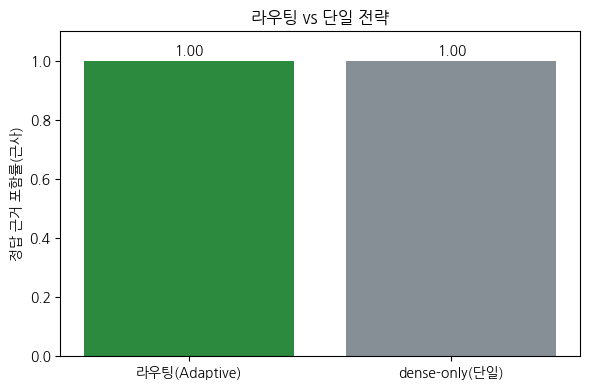

라우팅: 1.0  dense-only: 1.0


In [18]:
# 각 전략이 '정답 근거가 될 만한 핵심어'를 컨텍스트에 담았는지로 효과를 근사 측정
GOLD_KW = {
    "제품코드 NT-9000은 무엇인가?": "NT-9000",
    "노바테크 CEO 이름이 정확히 뭐였지?": "김하늘",
    "전기차에 들어가는 친환경 배터리를 만드는 회사는?": "그린모빌리티",
    "데이터센터 칩 시장에서 노바테크랑 다투는 곳은?": "퀀텀칩",
    "노바테크의 공급사이면서 퀀텀칩에도 납품하는 회사는?": "정밀소재",
    "노바테크 경쟁사의 공통 공급사는 어디인가?": "정밀소재",
}
def ctx_hit(contexts, kw):
    return 1 if contexts and any(kw in c for c in contexts) else 0

routed_hits, dense_hits = [], []
for q, kw in GOLD_KW.items():
    r = routed_rag(q)                         # 라우팅 경로
    routed_hits.append(ctx_hit(r["contexts"], kw))
    dense_hits.append(ctx_hit(dense_search(q), kw))   # 항상 dense만 쓰는 단일 전략

import numpy as np
labels = ["라우팅(Adaptive)", "dense-only(단일)"]
vals = [float(np.mean(routed_hits)), float(np.mean(dense_hits))]
plt.figure(figsize=(6,4))
bars = plt.bar(labels, vals, color=["#2b8a3e", "#868e96"])
for b, v in zip(bars, vals): plt.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1); plt.ylabel("정답 근거 포함률(근사)"); plt.title("라우팅 vs 단일 전략")
plt.tight_layout(); plt.show()
print("라우팅:", round(vals[0],3), " dense-only:", round(vals[1],3))

## 직접 해보기: 나만의 질문 라우팅
- 직접 만든 질문이 어떤 전략으로 라우팅되는지, 그게 적절한지 확인

In [19]:
# 직접 해보기: 아래 질문을 바꿔 라우팅 결과를 확인하세요.
# 힌트: 코드/모델명이 들어가면 keyword, 의역이면 semantic, 관계연결이면 relational, 상식이면 simple_fact로 가는지 보세요.
my_q = "노바테크의 자회사가 만드는 것은 무엇과 관련 있나?"   # ← 자유롭게 수정
out = routed_rag(my_q, verbose=True)
print("선택된 전략:", out["strategy"])

[relational] 노바테크의 자회사가 만드는 것은 무엇과 관련 있나?
  근거: ['노바테크의 CEO는 김하늘', '노바테크의 경쟁사는 퀀텀칩', '노바테크의 공급사는 정밀소재', '노바테크의 자회사는 노바소프트', '퀀텀칩의 공급사는 정밀소재']
  답: 주어진 근거에는 노바테크의 자회사인 **노바소프트**가 무엇을 만드는지에 대한 정보가 없습니다. 따라서 알 수 없습니다.

선택된 전략: relational


## 직접 해보기: 라벨된 질문 추가 후 정확도 재측정
- 새 질문에 정답 전략 라벨을 달고 라우팅 정확도가 어떻게 변하는지 보기

In [20]:
# 직접 해보기: 질문셋에 새 항목을 추가하고 정확도를 다시 재 보세요.
# 힌트: 아래 주석을 풀면 의미형 1개가 추가됩니다.
# QUERYSET.append({"q": "선박 탄소배출을 줄인 친환경 연료 회사는?", "label": "semantic"})
preds = [(route_query(x["q"])["strategy"], x["label"]) for x in QUERYSET]
acc2 = sum(p == l for p, l in preds) / len(preds)
print(f"현재 질문셋 라우팅 정확도: {acc2:.2%}")

현재 질문셋 라우팅 정확도: 87.50%


## 검증
- 분류 결과의 유효 범위와 라우팅 정확도를 자동 점검

In [21]:
import numpy as np

# 1) 분류기는 항상 '유효한 4개 전략' 중 하나만 돌려줘야 한다(enum 강제 확인)
preds = [route_query(x["q"])["strategy"] for x in QUERYSET]
assert all(p in STRATEGIES for p in preds), f"전략은 {STRATEGIES} 중 하나여야 한다"

# 2) 단순사실형은 no-retrieval(검색 없음)로 가야 비용/지연을 아낀다 — 표본 점검
sf = next(x for x in QUERYSET if x["label"] == "simple_fact")
r_sf = routed_rag(sf["q"])
assert r_sf["contexts"] is None or r_sf["strategy"] == "simple_fact", \
    "단순사실형은 검색을 건너뛰는 게 이상적"

# 3) 라우팅 정확도가 무작위(25%)보다 확실히 높아야 한다(라우터가 학습 없이도 동작)
acc = float(np.mean([p == x["label"] for p, x in zip(preds, QUERYSET)]))
assert acc >= 0.5, f"라우팅 정확도 {acc:.2%}가 너무 낮다(무작위 25% 이상 기대)"

# 4) graph-stub은 관계 사실 문장을 실제로 돌려준다
assert len(graph_search("노바테크 공급사")) >= 1, "graph-stub이 관계 사실을 반환해야 한다"

print(f"모든 검증 통과: 전략 유효범위·단순사실 직답·라우팅 정확도({acc:.0%})·graph 반환 정상")

모든 검증 통과: 전략 유효범위·단순사실 직답·라우팅 정확도(88%)·graph 반환 정상


## 확장 과제

1. **Hybrid 경로 추가**: 키워드+의미가 섞인 질문을 위해 `hybrid` 전략(BM25+dense RRF 융합)을 enum과 `DISPATCH`에 추가하고 라우터 설명도 보강해 보기
2. **신뢰도 기반 폴백**: 라우터가 고른 전략의 검색 결과가 비면(예: graph에서 엔티티 매칭 0건) **dense로 폴백**하도록 `routed_rag`를 확장해 보기
3. **비용/지연 측정**: 전략별 호출 시간과 토큰을 기록해, no-retrieval이 검색 경로 대비 얼마나 빠르고 싼지 표로 만들어 보기
4. **분류 모델 비교**: `MODEL_ROUTER`를 `claude-haiku-4-5`(저가)와 `claude-opus-4-8`(고정확)로 바꿔 라우팅 정확도·비용 트레이드오프를 비교해 보기
5. **실제 graph로 승급**: graph-stub을 lab5의 트리플 추출(Claude)→networkx 파이프라인으로 교체해 진짜 multi-hop 추론을 라우팅 경로에 연결해 보기

> **운영 한 줄 요약**: "모든 질문에 같은 검색은 낭비." 라우터는 질문 유형을 읽어 **맞는 전략으로 보내** 정확도와 비용을 동시에 잡는 Adaptive RAG의 핵심 (사후평가 Q5: 증상→처방과 직결)